In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
import os
import pickle
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *


Default device set to: cuda


# define atlas and dirs

In [2]:
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')

# Get Vs for mdtb_1 and mdtb_2 from nettekoven 32

In [3]:
model_dir = f'{cerebellum_dir}/ProbabilisticParcellationModel/Models/Models_03/'
model_name='NettekovenSym32_space-MNISymC2_D5.pickle'
with open(model_dir+model_name, 'rb') as f:
    full_model = pickle.load(f)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V
VL_mdtb_1 = mdtb_1_Vs.cpu().numpy()
#exclude rest because it will be removed from the data in the centering step
VL_mdtb_1 = VL_mdtb_1[:28,:]

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V
VL_mdtb_2 = mdtb_2_Vs.cpu().numpy()


In [4]:
lut_file_dir = f'{cerebellum_dir}/ProbabilisticParcellationModel/Atlases/NettekovenSym32.lut'
lut = pd.read_csv(lut_file_dir, sep=' ', header=None)
# ge the parcel names from the 4th column
parcel_names = lut.iloc[:,4].values
parcel_names = parcel_names[1:]
len(parcel_names)

32

# Load data

- mdtb_1 - run: Data used to make libray of tasks and to use task batteries for parcellations
- mdtb_1 - all: Data used to pick the Vs of the top parcels
- mdtb_2 - all: Data used to test parcellation predicition error

In [5]:
MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0
data_mdtb_s1_run = data_mdtb_s1_run[:,:,:]


data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]


data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


recenter data around rest so that the variance in the Glibrary is signal compared to rest  
centers each row around the rest in its run and remove the rest row from each run


In [6]:
data_mdtb_s1_run,info_mdtb_1_run = ut.recenter_fmri_data(data_mdtb_s1_run,info_mdtb_1_run,task_column_name='cond_name',center_condition='rest')
print(data_mdtb_s1_run.shape)

data_mdtb_s1_all,info_mdtb_1_all = ut.recenter_fmri_data(data_mdtb_s1_all,info_mdtb_1_all,task_column_name='cond_name',center_condition='rest')
print(data_mdtb_s1_all.shape)



(24, 448, 6918)
(24, 28, 6918)


In [7]:
def build_battery_dataset(YLib, info, combination, n_repeats=1):
    """
    Constructs a dataset based on a task battery combination.
    
    Parameters:
        YLib (numpy.ndarray): The full data array of shape (subjects, regressors, voxels).
        info (pandas.DataFrame): Information about regressors.
        combination (list): List of indices to include in battery dataset
        n_repeats (int): how much data you want for that combination, default is 1 meaning just make one artificial run of the combination
    
    Returns:
        final_dataset (numpy.ndarray): The constructed task battery dataset of shape (subjects, regressors, voxels).
    """
    # list to include n_repeats of the combination dataset (artificial runs)
    Y_subset_list = []
    total_runs = info['run'].nunique()
    
    # to make sure no regressor is chosen twice across n_repeats
    selected_indices = []
    for _ in range(n_repeats):
        Y_subset = []
        
        task_groups = info.groupby(['task_num_uni', 'cond_num'])
        task_only_groups = info.groupby(['task_num_uni'])
        
        for idx in combination:
            task_num = info.loc[idx, 'task_num_uni']
            cond_num = info.loc[idx, 'cond_num']
            
           # Get regressor list for the 'task'
            task_group = task_only_groups.get_group(task_num)
            task_indices = task_group.index.tolist()
            
            # Get regressor list for the 'condition of interest'
            condition_group = task_groups.get_group((task_num, cond_num))
            condition_indices = condition_group.index.tolist()
            
            # Determine if it's a task or condition
            num_task_regressors = len(task_indices) // total_runs  # if result is > 1, it's a task with multiple conditions
            
            # Never choose the same regressor twice
            chosen_indices = []
            while len(chosen_indices) < num_task_regressors:
                chosen_idx = np.random.choice(condition_indices)
                if chosen_idx not in selected_indices and chosen_idx not in chosen_indices: #hasn't been chosen for the preview repeat and hasn't been chosen if it's a condition
                    chosen_indices.append(chosen_idx)
                    selected_indices.append(chosen_idx)

            # if it's a 10s condition then average 3x10s to get 30s for example
            averaged_vector = np.mean(YLib[:,chosen_indices, :], axis=1)
            Y_subset.append(averaged_vector)
        
        # make dataset for current repeat and append to the list
        Y_subset = np.stack(Y_subset, axis=1)  
        Y_subset_list.append(Y_subset)
    
    # Average repeats
    stacked_Y = np.stack(Y_subset_list, axis=0)
    final_dataset = np.mean(stacked_Y, axis=0)
    return final_dataset

# Define mask used for top parcel identification, Glibrary estimation and evaluation of predicition error

In [8]:
# For this we are using whole cerebellum
ROI_indices = np.arange(data_mdtb_s1_run.shape[2])

# Find the most important parcels in ROI

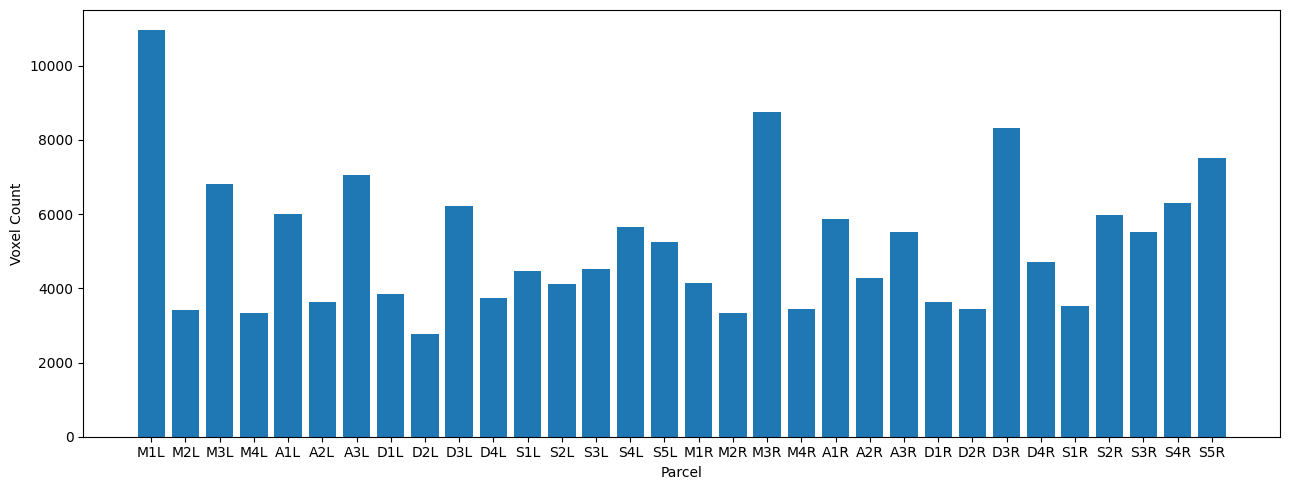

In [9]:
# get top 4 parcels with highest voxel counts within ROI
total_parcel_counts = np.zeros(32)

for subject_data in data_mdtb_s1_all:
    data = subject_data[:,ROI_indices]
    
    data_projected = VL_mdtb_1.T @ data
    data_projected_onehot = ev.get_U_hat_one_hot_np(data_projected)[0]
    
    total_parcel_counts += np.sum(data_projected_onehot, axis=1)

plt.figure(figsize=(13, 5))
plt.bar(range(1, 33), total_parcel_counts, tick_label=parcel_names)
plt.xlabel('Parcel')
plt.ylabel('Voxel Count')
plt.tight_layout()
plt.show()

# order the parcels by voxel count across all subjects
top_parcels = np.argsort(total_parcel_counts)[::-1]


# Get crossvalidated second moment matrix (GLib)

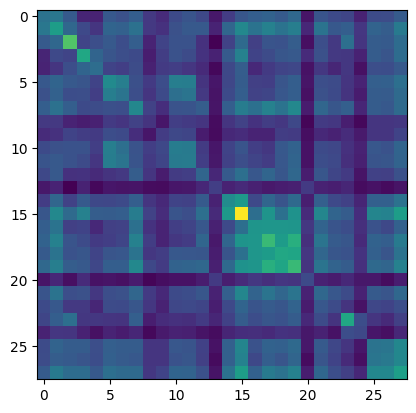

In [10]:
cond_vec = np.tile(np.arange(1, 28 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 28)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib)

# Build dataframes with different task battery size (n_tasks) and different number of parcels (n_parcels) and evaluate

In [11]:
battery_sizes = [3,4,5,6,7,8,10,12,14,16,18,20,22,24]
parcel_sizes = [2,4,6,8,10,12,14]

battery_sizes = [4,8]
parcel_sizes = [3]


In [ ]:
results_df = pd.DataFrame()

for n_parcel in parcel_sizes:
    print(f"Processing parcel size: {n_parcel}")
    for n_task in battery_sizes:
        print(f"Processing battery size: {n_task}")

        # only use top n parcels
        VLib = VL_mdtb_1[:,top_parcels[:n_parcel]]
        vtest = VL_mdtb_2[:,top_parcels[:n_parcel]]

        # Generate possible battery combinations for current battery size and evaluate each battery
        D = ut.build_combinations(G_Lib, strategy='random',n_iter=100,n_tasks=n_task,seed=1,replacement=False)
        D = D.reset_index(drop=True)
        D_ev = ev.real_evaluate_dataframe_multiregion(D, data_mdtb_s1_run,info_mdtb_1_run,VLib,data_mdtb_s2_all, vtest,ROI_indices)

        D_ev['n_parcel'] = n_parcel
        D_ev['n_task'] = n_task

        results_df = pd.concat([results_df, D_ev], ignore_index=True)
    


Processing parcel size: 3
Processing battery size: 4
Processing combination: 0
Processing combination: 10
Processing combination: 20
Processing combination: 30
Processing combination: 40
Processing combination: 50
Processing combination: 60
Processing combination: 70
Processing combination: 80
Processing combination: 90
Processing combination: 100
Processing combination: 110
Processing combination: 120
Processing combination: 130
Processing combination: 140
Processing combination: 150
Processing combination: 160
Processing combination: 170
Processing combination: 180
Processing combination: 190
Processing combination: 200
Processing combination: 210
Processing combination: 220
Processing combination: 230
Processing combination: 240
Processing combination: 250
Processing combination: 260
Processing combination: 270
Processing combination: 280
Processing combination: 290
Processing combination: 300
Processing combination: 310
Processing combination: 320


KeyboardInterrupt: 

In [ ]:
name = os.path.join(base_dir, 'OptimalBattery', 'cerebellum_MDTB_ses-01_ses-02_results.tsv')

# save to tsv
# results_df.to_csv(name, sep="\t", index=False)

#load
results_df = pd.read_csv(name, sep="\t")

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

# Asses the different criteria

In [ ]:
n_iter = 100
confidence = 0.95
metrics  = ["variance", "variance_mc","log_det_mc"]
bootstrap_results = []
battery_sizes = results_df['n_task'].unique()
parcel_sizes = results_df['n_parcel'].unique()

for i in parcel_sizes:
    print(f"Processing parcel size: {i}")
    for j in battery_sizes:
        print(f"Processing battery size: {j}")
        subset = results_df[(results_df['n_task'] == j) & (results_df['n_parcel'] == i)]
        num_samples = len(subset)
        metric_cos_values = {metric: [] for metric in metrics}
    
        for _ in range(n_iter):
            resampled = subset.sample(n=num_samples, replace=True)
            
            for metric in metrics:
                best_combination = resampled.nlargest(1, metric).sample(1)
                metric_cos_values[metric].append(best_combination['cos'])

        # Compute statistics for each metric
        for metric, cos_values in metric_cos_values.items():
            mean_cos = np.mean(cos_values)
            lower_ci, upper_ci = np.percentile(cos_values, [(1-confidence)/2 * 100, (1 + confidence)/2 * 100])
            
            bootstrap_results.append({
                'n_parcel': i,
                'n_task': j,
                'metric': metric,
                'mean_cos': mean_cos,
                'lower_ci': lower_ci,
                'upper_ci': upper_ci
            })

bootstrap_df = pd.DataFrame(bootstrap_results)


Processing parcel size: 2
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 10
Processing battery size: 12
Processing battery size: 14
Processing battery size: 16
Processing battery size: 18
Processing battery size: 20
Processing battery size: 22
Processing battery size: 24
Processing parcel size: 4
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 10
Processing battery size: 12
Processing battery size: 14
Processing battery size: 16
Processing battery size: 18
Processing battery size: 20
Processing battery size: 22
Processing battery size: 24
Processing parcel size: 6
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing batt

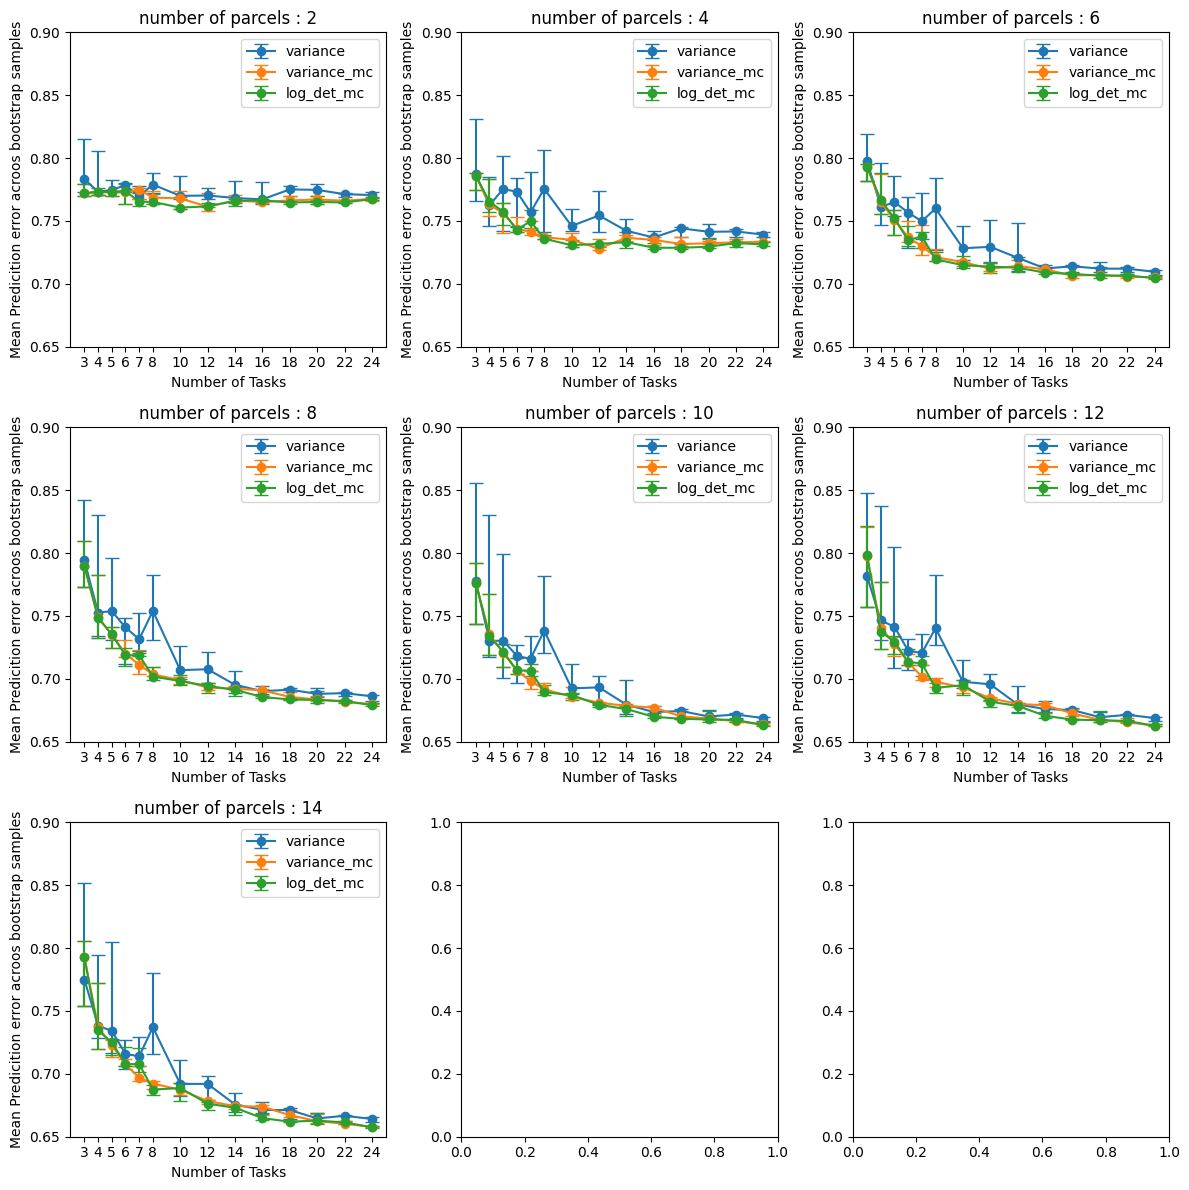

In [ ]:
num_parcels = len(parcel_sizes)

# Determine grid layout (square-like)
ncols = int(np.ceil(np.sqrt(num_parcels)))  
nrows = int(np.ceil(num_parcels / ncols))  
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows), sharex=False)

axes = np.array(axes).flatten()

for ax, parcel in zip(axes, parcel_sizes):
    subset = bootstrap_df[bootstrap_df['n_parcel'] == parcel]

    for metric in metrics:
        metric_subset = subset[subset['metric'] == metric]
        ax.errorbar(
            metric_subset['n_task'], 
            metric_subset['mean_cos'], 
            yerr=[metric_subset['mean_cos'] - metric_subset['lower_ci'], 
                  metric_subset['upper_ci'] - metric_subset['mean_cos']], 
            fmt='o-', capsize=5, label=metric
        )

    ax.set_title(f"number of parcels : {parcel}")
    ax.set_xlabel("Number of Tasks")
    ax.set_ylabel("Mean Predicition error acroos bootstrap samples")
    ax.set_xticks(sorted(subset['n_task'].unique()))
    ax.legend()

    ax.set_ylim(0.65, 0.9)

plt.tight_layout()
plt.show()
